# Experimental Model Debugging and Enhancement

**Strategy**: Build upon what works (Conformer1D) rather than fixing what's broken (MultivarWav2Vec2)

**Goals**:
1. Debug MultivarWav2Vec2 bugs (positional encoding, attention masking) to understand what went wrong
2. Enhance working Conformer1D by adding temporal transformer (dual architecture)
3. Compare all approaches side-by-side
4. Decide which architecture to use going forward

**Approach**: All model definitions inline in this notebook - no file edits until we verify what works

## Section 1: Setup and Data Loading

In [ ]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from einops import rearrange, repeat

plt.style.use('default')
sns.set_palette("husl")
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("✓ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

✓ Imports complete
PyTorch version: 2.10.0+cu126
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4090


In [ ]:
# Add paths
project_root = Path.cwd()
sys.path.insert(0, str(project_root / 'benchmark'))
sys.path.insert(0, str(project_root / 'code'))

from config_benchmark import BenchmarkConfig

config = BenchmarkConfig()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"✓ Configuration loaded")
print(f"Device: {device}")

✓ Configuration loaded
Device: cuda


In [ ]:
# Load patient subset (same as debug notebook)
data_dir = Path(config.OUTPUT_DATA_DIR) / "all_windows_per_patient_global_norm"
selected_patients = ['sub-RID0106', 'sub-RID0020', 'sub-RID0278']

print(f"Loading data from: {data_dir}")
print(f"Selected patients: {selected_patients}\n")

all_signals, all_coords, all_regs, all_labels = [], [], [], []
max_channels = 0

for patient_id in selected_patients:
    file_path = data_dir / f"{patient_id}.npz"
    if not file_path.exists():
        print(f"  ✗ {patient_id}: Not found")
        continue
    
    data = np.load(file_path, allow_pickle=True)
    signals = data['signals'].astype(np.float32)
    coords = data['coords']
    regs = data['regs']
    labels = data['labels']
    
    max_channels = max(max_channels, signals.shape[1])
    n_ictal = np.sum(labels == 1)
    n_interictal = np.sum(labels == 0)
    
    print(f"  ✓ {patient_id}: {len(signals)} windows, {signals.shape[1]} channels")
    print(f"      Ictal: {n_ictal}, Interictal: {n_interictal}")
    
    all_signals.append(signals)
    all_coords.append(coords)
    all_regs.append(regs)
    all_labels.append(labels)

print(f"\nMax channels: {max_channels}")

Loading data from: C:\Users\sirrus\Desktop\ieeg_sz_embedding\data\all_windows_per_patient_global_norm
Selected patients: ['sub-RID0106', 'sub-RID0020', 'sub-RID0278']

  ✓ sub-RID0106: 645 windows, 94 channels
      Ictal: 130, Interictal: 515
  ✓ sub-RID0020: 1010 windows, 74 channels
      Ictal: 9, Interictal: 1001
  ✓ sub-RID0278: 310 windows, 52 channels
      Ictal: 58, Interictal: 252

Max channels: 94


In [ ]:
# Pad to 150 channels
channel_buffer_size = 150

padded_signals, padded_regs = [], []
for signals, regs, labels in zip(all_signals, all_regs, all_labels):
    n_win, n_ch, n_time = signals.shape
    
    padded_sig = np.zeros((n_win, channel_buffer_size, n_time), dtype=np.float32)
    padded_reg = np.zeros((n_win, channel_buffer_size), dtype=regs.dtype)
    
    n_copy = min(n_ch, channel_buffer_size)
    padded_sig[:, :n_copy, :] = signals[:, :n_copy, :]
    padded_reg[:, :n_copy] = regs[:, :n_copy]
    
    padded_signals.append(padded_sig)
    padded_regs.append(padded_reg)

X_signals = np.concatenate(padded_signals, axis=0)
X_regs = np.concatenate(padded_regs, axis=0)
y_labels = np.concatenate(all_labels, axis=0)

X_signals = np.nan_to_num(X_signals, 0.0)

print(f"✓ Dataset prepared:")
print(f"  Shape: {X_signals.shape}")
print(f"  Ictal: {np.sum(y_labels==1)} ({100*np.sum(y_labels==1)/len(y_labels):.1f}%)")
print(f"  Interictal: {np.sum(y_labels==0)} ({100*np.sum(y_labels==0)/len(y_labels):.1f}%)")

✓ Dataset prepared:
  Shape: (1965, 150, 2560)
  Ictal: 197 (10.0%)
  Interictal: 1768 (90.0%)


In [ ]:
# Train/val/test splits
X_train_idx, X_temp_idx, y_train, y_temp = train_test_split(
    np.arange(len(y_labels)), y_labels, 
    test_size=0.3, random_state=42, stratify=y_labels
)

X_val_idx, X_test_idx, y_val, y_test = train_test_split(
    X_temp_idx, y_temp,
    test_size=0.5, random_state=42, stratify=y_temp
)

# Calculate class weights
n_samples = len(y_train)
class_counts = np.bincount(y_train)
class_weights = torch.FloatTensor(n_samples / (2 * class_counts)).to(device)

print(f"✓ Splits: Train={len(X_train_idx)}, Val={len(X_val_idx)}, Test={len(X_test_idx)}")
print(f"Class weights: {class_weights.cpu().numpy()}")

✓ Splits: Train=1375, Val=295, Test=295
Class weights: [0.5557801 4.981884 ]


## Section 2: Debug MultivarWav2Vec2 Issues

Goal: Understand what's broken (not necessarily fix it)

In [ ]:
### Test 2.1: Positional Encoding Bug

def test_positional_encoding():
    """Test if positional encoding dimensions match"""
    from model_classifier import MultivarWav2Vec2Classifier
    
    print("="*80)
    print("TESTING POSITIONAL ENCODING")
    print("="*80)
    
    model = MultivarWav2Vec2Classifier(num_classes=2).to(device)
    
    # Create test input
    x = torch.randn(2, 150, 2560).to(device)
    regs = torch.randint(0, 41, (2, 150)).to(device)
    
    # Hook into positional encoder
    pe_info = {}
    def hook_fn(module, input, output):
        pe_info['input_shape'] = input[0].shape
        pe_info['output_shape'] = output.shape
        pe_info['region_emb_shape'] = module.region_embedding.weight.shape
        pe_info['frame_emb_shape'] = module.frame_embedding.weight.shape
        pe_info['d_model'] = module.d_model
        pe_info['max_regions'] = module.max_regions
        pe_info['max_frames'] = module.max_frames
    
    hook = model.encoder.spatiotemporal_pos_encoder.register_forward_hook(hook_fn)
    
    try:
        with torch.no_grad():
            logits = model(x, regs)
        
        print(f"\n✓ Forward pass successful")
        print(f"\nPositional Encoding Info:")
        print(f"  Input shape: {pe_info['input_shape']}")
        print(f"  Output shape: {pe_info['output_shape']}")
        print(f"  d_model: {pe_info['d_model']}")
        print(f"  Max regions: {pe_info['max_regions']}")
        print(f"  Max frames: {pe_info['max_frames']}")
        print(f"  Region embedding: {pe_info['region_emb_shape']}")
        print(f"  Frame embedding: {pe_info['frame_emb_shape']}")
        
        # Check if dimensions match
        expected_d = 32  # ft_enc_dims[-1] from config
        actual_d = pe_info['d_model']
        if expected_d == actual_d:
            print(f"\n✓ Dimensions match correctly: {expected_d}")
        else:
            print(f"\n✗ DIMENSION MISMATCH: expected {expected_d}, got {actual_d}")
            
    except Exception as e:
        print(f"\n✗ Error during forward pass: {e}")
        import traceback
        traceback.print_exc()
    
    finally:
        hook.remove()

test_positional_encoding()

TESTING POSITIONAL ENCODING
  Note: Adjusted spatial_transformer_heads from 7 to 8

✓ Forward pass successful

Positional Encoding Info:
  Input shape: torch.Size([2, 150, 20, 32])
  Output shape: torch.Size([2, 150, 20, 32])
  d_model: 32
  Max regions: 41
  Max frames: 20
  Region embedding: torch.Size([42, 32])
  Frame embedding: torch.Size([20, 32])

✓ Dimensions match correctly: 32


In [ ]:
### Test 2.2: Attention Mask Bug

def test_attention_masks():
    """Check if padded channels are properly masked"""
    from model_classifier import MultivarWav2Vec2Classifier
    
    print("\n" + "="*80)
    print("TESTING ATTENTION MASKS")
    print("="*80)
    
    model = MultivarWav2Vec2Classifier(num_classes=2).to(device)
    
    # Create input with known padding (only first 50 channels real)
    x = torch.randn(2, 150, 2560).to(device)
    regs = torch.zeros(2, 150, dtype=torch.long).to(device)
    regs[:, :50] = torch.randint(1, 41, (2, 50)).to(device)  # Only first 50 real
    
    print(f"\nInput setup:")
    print(f"  Total channels: 150")
    print(f"  Real channels: 50 (indices 0-49)")
    print(f"  Padded channels: 100 (indices 50-149)")
    print(f"  Regions for real channels: {regs[0, :50].unique().tolist()}")
    print(f"  Regions for padded channels: {regs[0, 50:].unique().tolist()}")
    
    # Hook transformers to check masks
    spatial_info = {}
    temporal_info = {}
    
    def spatial_hook(module, input, output):
        # Input to transformer is (batch, seq_len, hidden_dim)
        spatial_info['input_shape'] = input[0].shape if isinstance(input, tuple) else input.shape
        spatial_info['output_shape'] = output.shape
        
    def temporal_hook(module, input, output):
        temporal_info['input_shape'] = input[0].shape if isinstance(input, tuple) else input.shape
        temporal_info['output_shape'] = output.shape
    
    s_hook = model.encoder.spatial_transformer.register_forward_hook(spatial_hook)
    t_hook = model.encoder.temporal_transformer.register_forward_hook(temporal_hook)
    
    try:
        with torch.no_grad():
            logits = model(x, regs)
        
        print(f"\n✓ Forward pass successful")
        print(f"\nSpatial Transformer:")
        print(f"  Input shape: {spatial_info['input_shape']}")
        print(f"  Output shape: {spatial_info['output_shape']}")
        
        print(f"\nTemporal Transformer:")
        print(f"  Input shape: {temporal_info['input_shape']}")
        print(f"  Output shape: {temporal_info['output_shape']}")
        
        print(f"\nFinal logits: {logits}")
        print(f"Logit difference (class 0 - class 1): {(logits[:, 0] - logits[:, 1]).cpu().numpy()}")
        
        # Test with all-padded input
        x_all_pad = torch.randn(2, 150, 2560).to(device)
        regs_all_pad = torch.zeros(2, 150, dtype=torch.long).to(device)
        logits_all_pad = model(x_all_pad, regs_all_pad)
        
        print(f"\nAll-padded input logits: {logits_all_pad}")
        print(f"\n⚠️ If logits are similar for real vs all-padded, masking is BROKEN")
        
    except Exception as e:
        print(f"\n✗ Error: {e}")
        import traceback
        traceback.print_exc()
    
    finally:
        s_hook.remove()
        t_hook.remove()

test_attention_masks()


TESTING ATTENTION MASKS
  Note: Adjusted spatial_transformer_heads from 7 to 8

Input setup:
  Total channels: 150
  Real channels: 50 (indices 0-49)
  Padded channels: 100 (indices 50-149)
  Regions for real channels: [4, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 24, 25, 26, 27, 28, 30, 32, 33, 34, 38, 40]
  Regions for padded channels: [0]

✓ Forward pass successful

Spatial Transformer:
  Input shape: torch.Size([2, 150, 640])
  Output shape: torch.Size([2, 150, 640])

Temporal Transformer:
  Input shape: torch.Size([2, 21, 4800])
  Output shape: torch.Size([2, 21, 4800])

Final logits: tensor([[ 0.0721,  0.2973],
        [ 0.2765, -0.0605]], device='cuda:0')
Logit difference (class 0 - class 1): [-0.22512133  0.33706403]

All-padded input logits: tensor([[-0.1112, -0.2901],
        [ 0.1735,  0.0856]], device='cuda:0', grad_fn=<AddmmBackward0>)

⚠️ If logits are similar for real vs all-padded, masking is BROKEN


In [ ]:
# Import TransformerEncoder from working Conformer
sys.path.insert(0, str(project_root / 'benchmark' / 'models' / 'conformer'))
from conformer_1d import TransformerEncoder, MultiHeadAttention, ResidualAdd, FeedForwardBlock

print("✓ Imported transformer components from working Conformer1D")

✓ Imported transformer components from working Conformer1D


In [ ]:
class ChannelCNNEncoderTemporal(nn.Module):
    """
    Modified CNN encoder that preserves temporal structure.
    Instead of pooling to single vector, output temporal sequence.
    """
    def __init__(self, embed_dim=128, n_frames=20):
        super().__init__()
        self.n_frames = n_frames
        
        self.conv1 = nn.Conv1d(1, 32, 7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(4)
        
        self.conv2 = nn.Conv1d(32, 64, 5, stride=2, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(4)
        
        self.conv3 = nn.Conv1d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        
        # Instead of AdaptiveAvgPool1d(1), use adaptive to n_frames
        self.adaptive_pool = nn.AdaptiveAvgPool1d(n_frames)
        self.fc = nn.Linear(128, embed_dim)
        
    def forward(self, x):
        # x: (batch, 1, timesteps)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.adaptive_pool(x)  # (batch, 128, n_frames)
        x = x.transpose(1, 2)  # (batch, n_frames, 128)
        x = self.fc(x)  # (batch, n_frames, embed_dim)
        return x

# Test the encoder
test_encoder = ChannelCNNEncoderTemporal(embed_dim=128, n_frames=20)
test_input = torch.randn(4, 1, 2560)
test_output = test_encoder(test_input)
print(f"✓ ChannelCNNEncoderTemporal")
print(f"  Input: {test_input.shape}")
print(f"  Output: {test_output.shape}")
print(f"  Expected: (4, 20, 128)")

✓ ChannelCNNEncoderTemporal
  Input: torch.Size([4, 1, 2560])
  Output: torch.Size([4, 20, 128])
  Expected: (4, 20, 128)


In [ ]:
class Conformer1DDual(nn.Module):
    """
    Conformer with dual transformers:
    1. Spatial: attend across channels (at each time point)
    2. Temporal: attend across time (after spatial aggregation)
    
    This mimics MultivarWav2Vec2 architecture but with simpler components.
    """
    def __init__(self, emb_size=128, depth_spatial=2, depth_temporal=4,
                 num_heads=8, n_classes=2, dropout=0.1, max_channels=150, n_frames=20):
        super().__init__()
        self.max_channels = max_channels
        self.n_frames = n_frames
        self.embed_dim = emb_size
        
        # Channel encoder (preserves temporal structure)
        self.channel_encoder = ChannelCNNEncoderTemporal(emb_size, n_frames)
        
        # Positional embeddings
        self.spatial_pos_embed = nn.Parameter(torch.randn(1, max_channels, emb_size))
        self.temporal_pos_embed = nn.Parameter(torch.randn(1, n_frames + 1, emb_size))
        
        # Spatial transformer (across channels)
        self.spatial_transformer = TransformerEncoder(depth_spatial, emb_size)
        
        # Temporal transformer (across frames)
        self.temporal_cls_token = nn.Parameter(torch.randn(1, 1, emb_size))
        self.temporal_transformer = TransformerEncoder(depth_temporal, emb_size)
        
        # Classification head
        self.norm = nn.LayerNorm(emb_size)
        self.dropout_layer = nn.Dropout(dropout)
        hidden_dim = emb_size * 2
        self.classifier = nn.Sequential(
            nn.Linear(emb_size, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_classes)
        )
    
    def forward(self, x):
        batch, channels, timesteps = x.shape
        
        # Encode each channel → (batch*channels, n_frames, embed_dim)
        x_reshaped = x.view(batch * channels, 1, timesteps)
        channel_embeds = self.channel_encoder(x_reshaped)  # (batch*channels, n_frames, embed_dim)
        
        # Reshape to (batch, channels, n_frames, embed_dim)
        channel_embeds = channel_embeds.view(batch, channels, self.n_frames, self.embed_dim)
        
        # Spatial transformer: attend across channels at each frame
        # Process all frames in parallel
        x_spatial = rearrange(channel_embeds, 'b c f d -> (b f) c d')
        x_spatial = x_spatial + self.spatial_pos_embed[:, :channels, :]
        x_spatial = self.spatial_transformer(x_spatial)  # (batch*n_frames, channels, embed_dim)
        
        # Aggregate channels (mean pooling across channel dimension)
        x_spatial = x_spatial.mean(dim=1)  # (batch*n_frames, embed_dim)
        x_spatial = rearrange(x_spatial, '(b f) d -> b f d', b=batch)
        
        # Temporal transformer: attend across frames
        cls_tokens = self.temporal_cls_token.expand(batch, -1, -1)
        x_temporal = torch.cat([cls_tokens, x_spatial], dim=1)
        x_temporal = x_temporal + self.temporal_pos_embed[:, :self.n_frames + 1, :]
        x_temporal = self.temporal_transformer(x_temporal)
        
        # Extract CLS token
        cls_output = x_temporal[:, 0]
        cls_output = self.norm(cls_output)
        cls_output = self.dropout_layer(cls_output)
        logits = self.classifier(cls_output)
        
        return logits

# Test Conformer1DDual
print("\n" + "="*80)
print("TESTING CONFORMER1DDUAL")
print("="*80)

model_dual = Conformer1DDual(emb_size=128, depth_spatial=2, depth_temporal=4, 
                              n_classes=2, max_channels=150, n_frames=20).to(device)

test_x = torch.randn(4, 150, 2560).to(device)
test_logits = model_dual(test_x)

print(f"\n✓ Conformer1DDual forward pass successful")
print(f"  Input: {test_x.shape}")
print(f"  Output: {test_logits.shape}")
print(f"  Expected: (4, 2)")
print(f"\n  Sample logits: {test_logits[:2]}")

# Count parameters
dual_params = sum(p.numel() for p in model_dual.parameters())
print(f"\n  Total parameters: {dual_params:,}")


TESTING CONFORMER1DDUAL

✓ Conformer1DDual forward pass successful
  Input: torch.Size([4, 150, 2560])
  Output: torch.Size([4, 2])
  Expected: (4, 2)

  Sample logits: tensor([[ 0.2692,  0.0134],
        [ 0.4010, -0.1549]], device='cuda:0', grad_fn=<SliceBackward0>)

  Total parameters: 902,914


In [ ]:
# Prepare dataloaders
batch_size = 16

train_dataset = TensorDataset(
    torch.FloatTensor(X_signals[X_train_idx]),
    torch.LongTensor(X_regs[X_train_idx]),
    torch.LongTensor(y_train)
)

val_dataset = TensorDataset(
    torch.FloatTensor(X_signals[X_val_idx]),
    torch.LongTensor(X_regs[X_val_idx]),
    torch.LongTensor(y_val)
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"✓ DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")

✓ DataLoaders created:
  Train batches: 86
  Val batches: 19


In [ ]:
# Update training function to handle region-based models
def train_model(model, model_name, train_loader, val_loader, num_epochs=20, lr=1e-3):
    """Generic training function - updated to handle region-based models"""
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
    best_val_loss = float('inf')
    
    print(f"\nTraining {model_name}...")
    print("="*60)
    
    for epoch in range(num_epochs):
        # Train
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        
        for signals, regs, labels in train_loader:
            signals, regs, labels = signals.to(device), regs.to(device), labels.to(device)
            signals = torch.nan_to_num(signals, posinf=0.0, neginf=0.0)
            
            optimizer.zero_grad()
            
            # Handle different model inputs
            if 'MultivarWav2Vec2' in model_name or 'Regions' in model_name or 'ST Model' in model_name:
                logits = model(signals, regs)
            else:
                logits = model(signals)
            
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * signals.size(0)
            _, predicted = torch.max(logits, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
        
        train_loss /= train_total
        train_acc = train_correct / train_total
        
        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        val_preds, val_true = [], []
        
        with torch.no_grad():
            for signals, regs, labels in val_loader:
                signals, regs, labels = signals.to(device), regs.to(device), labels.to(device)
                signals = torch.nan_to_num(signals, posinf=0.0, neginf=0.0)
                
                if 'MultivarWav2Vec2' in model_name or 'Regions' in model_name or 'ST Model' in model_name:
                    logits = model(signals, regs)
                else:
                    logits = model(signals)
                
                loss = criterion(logits, labels)
                
                val_loss += loss.item() * signals.size(0)
                _, predicted = torch.max(logits, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                
                val_preds.extend(predicted.cpu().numpy())
                val_true.extend(labels.cpu().numpy())
        
        val_loss /= val_total
        val_acc = val_correct / val_total
        val_f1 = f1_score(val_true, val_preds, average='binary')
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        
        if epoch % 5 == 0 or epoch == num_epochs - 1:
            print(f"Epoch {epoch+1:2d}: TrL={train_loss:.4f} TrA={train_acc:.4f} | "
                  f"VL={val_loss:.4f} VA={val_acc:.4f} VF1={val_f1:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
    
    print(f"✓ Best val loss: {best_val_loss:.4f}")
    return history

print("✓ Training function updated to handle region-based models")

✓ Training function updated to handle region-based models


### Test Conformer1DDual with Region Information

Now let's create a version that uses region embeddings for spatial attention

In [ ]:
class Conformer1DDualRegions(nn.Module):
    """
    Conformer with dual transformers + region embeddings:
    1. Spatial: attend across channels (at each time point) with region-based positional encoding
    2. Temporal: attend across time (after spatial aggregation)
    
    This combines the working Conformer architecture with region information like MultivarWav2Vec2.
    """
    def __init__(self, emb_size=128, depth_spatial=4, depth_temporal=4,
                 num_heads=8, n_classes=2, dropout=0.1, max_channels=150, 
                 n_frames=30, max_regions=42):
        super().__init__()
        self.max_channels = max_channels
        self.n_frames = n_frames
        self.embed_dim = emb_size
        self.max_regions = max_regions
        
        # Channel encoder (preserves temporal structure)
        self.channel_encoder = ChannelCNNEncoderTemporal(emb_size, n_frames)
        
        # Region embedding for spatial positional encoding (like MultivarWav2Vec2)
        self.region_embedding = nn.Embedding(max_regions, emb_size)
        
        # Frame positional embeddings for temporal
        self.temporal_pos_embed = nn.Parameter(torch.randn(1, n_frames + 1, emb_size))
        
        # Spatial transformer (across channels)
        self.spatial_transformer = TransformerEncoder(depth_spatial, emb_size)
        
        # Temporal transformer (across frames)
        self.temporal_cls_token = nn.Parameter(torch.randn(1, 1, emb_size))
        self.temporal_transformer = TransformerEncoder(depth_temporal, emb_size)
        
        # Classification head
        self.norm = nn.LayerNorm(emb_size)
        self.dropout_layer = nn.Dropout(dropout)
        hidden_dim = emb_size * 2
        self.classifier = nn.Sequential(
            nn.Linear(emb_size, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_classes)
        )
    
    def forward(self, x, regs):
        batch, channels, timesteps = x.shape
        
        # Encode each channel → (batch*channels, n_frames, embed_dim)
        x_reshaped = x.view(batch * channels, 1, timesteps)
        channel_embeds = self.channel_encoder(x_reshaped)  # (batch*channels, n_frames, embed_dim)
        
        # Reshape to (batch, channels, n_frames, embed_dim)
        channel_embeds = channel_embeds.view(batch, channels, self.n_frames, self.embed_dim)
        
        # Spatial transformer: attend across channels at each frame
        # Process all frames in parallel
        x_spatial = rearrange(channel_embeds, 'b c f d -> (b f) c d')
        
        # Add region-based positional embeddings
        # regs: (batch, channels) -> expand to (batch*n_frames, channels)
        regs_expanded = repeat(regs, 'b c -> (b f) c', f=self.n_frames)
        region_pos = self.region_embedding(regs_expanded)  # (batch*n_frames, channels, embed_dim)
        
        x_spatial = x_spatial + region_pos
        x_spatial = self.spatial_transformer(x_spatial)  # (batch*n_frames, channels, embed_dim)
        
        # Aggregate channels (mean pooling across channel dimension)
        x_spatial = x_spatial.mean(dim=1)  # (batch*n_frames, embed_dim)
        x_spatial = rearrange(x_spatial, '(b f) d -> b f d', b=batch)
        
        # Temporal transformer: attend across frames
        cls_tokens = self.temporal_cls_token.expand(batch, -1, -1)
        x_temporal = torch.cat([cls_tokens, x_spatial], dim=1)
        x_temporal = x_temporal + self.temporal_pos_embed[:, :self.n_frames + 1, :]
        x_temporal = self.temporal_transformer(x_temporal)
        
        # Extract CLS token
        cls_output = x_temporal[:, 0]
        cls_output = self.norm(cls_output)
        cls_output = self.dropout_layer(cls_output)
        logits = self.classifier(cls_output)
        
        return logits

# Test the model
print("\n" + "="*80)
print("TESTING CONFORMER1DDUAL WITH REGIONS")
print("="*80)

model_regions = Conformer1DDualRegions(
    emb_size=128, 
    depth_spatial=4, 
    depth_temporal=4, 
    n_classes=2, 
    max_channels=150, 
    n_frames=30,
    max_regions=42
).to(device)

test_x = torch.randn(4, 150, 2560).to(device)
test_regs = torch.randint(0, 42, (4, 150)).to(device)
test_logits = model_regions(test_x, test_regs)

print(f"\n✓ Conformer1DDualRegions forward pass successful")
print(f"  Input signals: {test_x.shape}")
print(f"  Input regions: {test_regs.shape}")
print(f"  Output: {test_logits.shape}")
print(f"  Expected: (4, 2)")
print(f"\n  Sample logits: {test_logits[:2]}")

# Count parameters
regions_params = sum(p.numel() for p in model_regions.parameters())
print(f"\n  Total parameters: {regions_params:,}")

print(f"\nConfiguration:")
print(f"  Spatial depth: 4")
print(f"  Temporal depth: 4")
print(f"  Frames: 30")
print(f"  Embed dim: 128")
print(f"  Max regions: 42")


TESTING CONFORMER1DDUAL WITH REGIONS

✓ Conformer1DDualRegions forward pass successful
  Input signals: torch.Size([4, 150, 2560])
  Input regions: torch.Size([4, 150])
  Output: torch.Size([4, 2])
  Expected: (4, 2)

  Sample logits: tensor([[-0.1811, -0.4543],
        [-0.2725, -0.3571]], device='cuda:0', grad_fn=<SliceBackward0>)

  Total parameters: 1,155,330

Configuration:
  Spatial depth: 4
  Temporal depth: 4
  Frames: 30
  Embed dim: 128
  Max regions: 42


In [ ]:
# Train the region-based model with config: 4 spatial, 4 temporal, 30 frames
print("\n" + "="*80)
print("TRAINING CONFORMER1DDUAL WITH REGIONS")
print("Config: Spatial=4, Temporal=4, Frames=30")
print("="*80)

model_regions_train = Conformer1DDualRegions(
    emb_size=128,
    depth_spatial=4,
    depth_temporal=4,
    n_classes=2,
    max_channels=150,
    n_frames=30,
    max_regions=42
).to(device)

history_regions = train_model(
    model_regions_train, 
    "Conformer1DDualRegions (S=4, T=4, F=30)", 
    train_loader, 
    val_loader, 
    num_epochs=20, 
    lr=1e-3
)

print("\n✓ Region-based model training complete")


TRAINING CONFORMER1DDUAL WITH REGIONS
Config: Spatial=4, Temporal=4, Frames=30

Training Conformer1DDualRegions (S=4, T=4, F=30)...
Epoch  1: TrL=0.6833 TrA=0.6676 | VL=0.5418 VA=0.8746 VF1=0.4478


KeyboardInterrupt: 

## Test New ST Model with Adaptive Pooling

Testing the Spatial-Temporal model with adaptive channel pooling (150→20 channels)

In [ ]:
# Import ST model
sys.path.insert(0, str(project_root / 'benchmark' / 'models' / 'spatial_temporal'))
from st_model import SpatialTemporalModel

print("=" * 80)
print("TESTING SPATIAL-TEMPORAL MODEL (WITH MEAN POOLING)")
print("=" * 80)

# Create ST model with mean pooling (like Conformer1DDualRegions)
model_st = SpatialTemporalModel(
    spatial_embed_dim=128,
    temporal_embed_dim=128,  # Same as spatial (using mean pooling)
    depth_spatial=6,
    depth_temporal=6,
    n_classes=2,
    max_channels=150,
    n_frames=30,
    n_spatial_tokens=20,  # Deprecated parameter
    max_regions=42,
    num_heads=8,
    dropout=0.1
).to(device)

# Test forward pass
test_x = torch.randn(4, 150, 2560).to(device)
test_regs = torch.randint(0, 42, (4, 150)).to(device)
test_logits = model_st(test_x, test_regs)

print(f"\n✓ ST Model forward pass successful")
print(f"  Input signals: {test_x.shape}")
print(f"  Input regions: {test_regs.shape}")
print(f"  Output: {test_logits.shape}")
print(f"  Expected: (4, 2)")
print(f"\n  Sample logits: {test_logits[:2]}")

# Count parameters
st_params = sum(p.numel() for p in model_st.parameters())
print(f"\n  Total parameters: {st_params:,}")

print(f"\nConfiguration:")
print(f"  Spatial: 6 layers, 128-dim embeddings")
print(f"  Temporal: 6 layers, 128-dim embeddings")
print(f"  Frames: 30")
print(f"  Aggregation: Mean pooling (channels → 1 per frame)")
print(f"  Max regions: 42")

print(f"\nArchitecture (simplified from adaptive pooling):")
print(f"  - Uses mean pooling for channel aggregation (like Conformer1DDualRegions)")
print(f"  - Each temporal frame has 128-dim features")
print(f"  - Uses region embeddings for spatial attention")

TESTING SPATIAL-TEMPORAL MODEL (WITH MEAN POOLING)

✓ ST Model forward pass successful
  Input signals: torch.Size([4, 150, 2560])
  Input regions: torch.Size([4, 150])
  Output: torch.Size([4, 2])
  Expected: (4, 2)

  Sample logits: tensor([[-0.1548, -0.5613],
        [-0.3120, -0.5321]], device='cuda:0', grad_fn=<SliceBackward0>)

  Total parameters: 1,685,250

Configuration:
  Spatial: 6 layers, 128-dim embeddings
  Temporal: 6 layers, 128-dim embeddings
  Frames: 30
  Aggregation: Mean pooling (channels → 1 per frame)
  Max regions: 42

Architecture (simplified from adaptive pooling):
  - Uses mean pooling for channel aggregation (like Conformer1DDualRegions)
  - Each temporal frame has 128-dim features
  - Uses region embeddings for spatial attention


In [ ]:
# Train ST model on patient subset
print("\n" + "=" * 80)
print("TRAINING ST MODEL (WITH MEAN POOLING)")
print("Config: Spatial=6, Temporal=6, Frames=30, Aggregation=Mean")
print("=" * 80)

model_st_train = SpatialTemporalModel(
    spatial_embed_dim=128,
    temporal_embed_dim=128,  # Same as spatial
    depth_spatial=6,
    depth_temporal=6,
    n_classes=2,
    max_channels=150,
    n_frames=30,
    n_spatial_tokens=20,  # Deprecated
    max_regions=42,
    num_heads=8,
    dropout=0.1
).to(device)

history_st = train_model(
    model_st_train,
    "ST Model (S=6, T=6, F=30, Mean)",
    train_loader,
    val_loader,
    num_epochs=20,
    lr=1e-3
)

print("\n✓ ST Model training complete")


TRAINING ST MODEL (WITH MEAN POOLING)
Config: Spatial=6, Temporal=6, Frames=30, Aggregation=Mean

Training ST Model (S=6, T=6, F=30, Mean)...
Epoch  1: TrL=0.6948 TrA=0.7055 | VL=0.6775 VA=0.8983 VF1=0.0000
Epoch  6: TrL=0.4560 TrA=0.7433 | VL=0.4443 VA=0.9390 VF1=0.6400
Epoch 11: TrL=0.5024 TrA=0.8342 | VL=0.3548 VA=0.8881 VF1=0.5600


KeyboardInterrupt: 

In [ ]:
# Compare all models including ST
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Combine all histories
all_comparison_histories = {
    'Conformer1D (Single)': histories['Conformer1D (Single Transformer)'],
    'Conformer1DDual (S=2,T=4)': histories['Conformer1DDual (Spatial + Temporal)'],
    'Conformer1DDualRegions (S=4,T=4,F=30)': history_regions,
    'ST Model (S=6,T=6,F=30,ST=20)': history_st
}

colors_all = ['blue', 'red', 'green', 'purple']

# Loss
for idx, (name, history) in enumerate(all_comparison_histories.items()):
    epochs = range(1, len(history['train_loss']) + 1)
    axes[0, 0].plot(epochs, history['train_loss'], color=colors_all[idx],
                    linestyle='-', label=f'{name} Train', linewidth=2, alpha=0.7)
    axes[0, 0].plot(epochs, history['val_loss'], color=colors_all[idx],
                    linestyle='--', label=f'{name} Val', linewidth=2, alpha=0.7)

axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Comparison (All Models)', fontweight='bold')
axes[0, 0].legend(fontsize=7)
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
for idx, (name, history) in enumerate(all_comparison_histories.items()):
    epochs = range(1, len(history['train_acc']) + 1)
    axes[0, 1].plot(epochs, history['train_acc'], color=colors_all[idx],
                    linestyle='-', label=f'{name} Train', linewidth=2, alpha=0.7)
    axes[0, 1].plot(epochs, history['val_acc'], color=colors_all[idx],
                    linestyle='--', label=f'{name} Val', linewidth=2, alpha=0.7)

axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy Comparison (All Models)', fontweight='bold')
axes[0, 1].legend(fontsize=7)
axes[0, 1].grid(True, alpha=0.3)

# F1 Score
for idx, (name, history) in enumerate(all_comparison_histories.items()):
    epochs = range(1, len(history['val_f1']) + 1)
    axes[1, 0].plot(epochs, history['val_f1'], color=colors_all[idx],
                    linestyle='-', label=name, linewidth=2)

axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('Validation F1 Score Comparison (All Models)', fontweight='bold')
axes[1, 0].legend(fontsize=7)
axes[1, 0].grid(True, alpha=0.3)

# Final metrics table
axes[1, 1].axis('off')
metrics_text = "FINAL METRICS\\n\\n"
for name, history in all_comparison_histories.items():
    # Shorten names for display
    short_name = name.replace('Conformer1DDualRegions', 'C1DDualReg')
    short_name = short_name.replace('Conformer1DDual', 'C1DDual')
    short_name = short_name.replace('Conformer1D', 'C1D')
    short_name = short_name.replace('ST Model', 'ST')
    
    metrics_text += f"{short_name}:\\n"
    metrics_text += f"  Loss: {min(history['val_loss']):.4f}\\n"
    metrics_text += f"  Acc:  {max(history['val_acc']):.4f}\\n"
    metrics_text += f"  F1:   {max(history['val_f1']):.4f}\\n\\n"

axes[1, 1].text(0.05, 0.5, metrics_text, fontsize=9, family='monospace',
                verticalalignment='center')

plt.tight_layout()
plt.savefig('test_all_models_comparison.png', dpi=150)
plt.show()

print("✓ Complete comparison plotted")

# Print comparison summary
print("\\n" + "=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
print(f"\\n{'Model':<40} {'Params':<12} {'Best Val Loss':<15} {'Best Val Acc':<15} {'Best Val F1':<10}")
print("-" * 95)

model_configs = {
    'Conformer1D (Single)': sum(p.numel() for p in models_to_test['Conformer1D (Single Transformer)'].parameters()),
    'Conformer1DDual (S=2,T=4)': sum(p.numel() for p in models_to_test['Conformer1DDual (Spatial + Temporal)'].parameters()),
    'Conformer1DDualRegions (S=4,T=4,F=30)': sum(p.numel() for p in model_regions_train.parameters()),
    'ST Model (S=6,T=6,F=30,ST=20)': sum(p.numel() for p in model_st_train.parameters())
}

for name, history in all_comparison_histories.items():
    params = model_configs[name]
    best_loss = min(history['val_loss'])
    best_acc = max(history['val_acc'])
    best_f1 = max(history['val_f1'])
    print(f"{name:<40} {params:<12,} {best_loss:<15.4f} {best_acc:<15.4f} {best_f1:<10.4f}")

print("\\n" + "=" * 80)

In [ ]:
# Compare with previous best models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Combine histories for comparison
comparison_histories = {
    'Conformer1D (Single)': histories['Conformer1D (Single Transformer)'],
    'Conformer1DDual (S=2,T=4)': histories['Conformer1DDual (Spatial + Temporal)'],
    'Conformer1DDualRegions (S=4,T=4,F=30)': history_regions
}

colors_comp = ['blue', 'red', 'green']

# Loss
for idx, (name, history) in enumerate(comparison_histories.items()):
    epochs = range(1, len(history['train_loss']) + 1)
    axes[0, 0].plot(epochs, history['train_loss'], color=colors_comp[idx], 
                    linestyle='-', label=f'{name} Train', linewidth=2, alpha=0.7)
    axes[0, 0].plot(epochs, history['val_loss'], color=colors_comp[idx], 
                    linestyle='--', label=f'{name} Val', linewidth=2, alpha=0.7)

axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Comparison (with Regions)', fontweight='bold')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
for idx, (name, history) in enumerate(comparison_histories.items()):
    epochs = range(1, len(history['train_acc']) + 1)
    axes[0, 1].plot(epochs, history['train_acc'], color=colors_comp[idx], 
                    linestyle='-', label=f'{name} Train', linewidth=2, alpha=0.7)
    axes[0, 1].plot(epochs, history['val_acc'], color=colors_comp[idx], 
                    linestyle='--', label=f'{name} Val', linewidth=2, alpha=0.7)

axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy Comparison (with Regions)', fontweight='bold')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

# F1 Score
for idx, (name, history) in enumerate(comparison_histories.items()):
    epochs = range(1, len(history['val_f1']) + 1)
    axes[1, 0].plot(epochs, history['val_f1'], color=colors_comp[idx], 
                    linestyle='-', label=name, linewidth=2)

axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('Validation F1 Score Comparison (with Regions)', fontweight='bold')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# Final metrics table
axes[1, 1].axis('off')
metrics_text = "FINAL METRICS (Best Epoch)\\n\\n"
for name, history in comparison_histories.items():
    short_name = name.replace('Conformer1DDualRegions', 'C1DDualReg').replace('Conformer1DDual', 'C1DDual').replace('Conformer1D', 'C1D')
    metrics_text += f"{short_name}:\\n"
    metrics_text += f"  Loss: {min(history['val_loss']):.4f}\\n"
    metrics_text += f"  Acc:  {max(history['val_acc']):.4f}\\n"
    metrics_text += f"  F1:   {max(history['val_f1']):.4f}\\n\\n"

axes[1, 1].text(0.05, 0.5, metrics_text, fontsize=10, family='monospace',
                verticalalignment='center')

plt.tight_layout()
plt.savefig('test_model_comparison_with_regions.png', dpi=150)
plt.show()

print("✓ Comparison with regions plotted")

# Print summary
print("\\n" + "="*80)
print("SUMMARY: CONFORMER1DDUAL WITH REGIONS")
print("="*80)
print(f"Best Val Loss: {min(history_regions['val_loss']):.4f}")
print(f"Best Val Acc:  {max(history_regions['val_acc']):.4f}")
print(f"Best Val F1:   {max(history_regions['val_f1']):.4f}")
print(f"\\nCompared to Conformer1D (Single):")
print(f"  Val Loss: {min(histories['Conformer1D (Single Transformer)']['val_loss']):.4f}")
print(f"  Val Acc:  {max(histories['Conformer1D (Single Transformer)']['val_acc']):.4f}")
print(f"  Val F1:   {max(histories['Conformer1D (Single Transformer)']['val_f1']):.4f}")

In [ ]:
def train_model(model, model_name, train_loader, val_loader, num_epochs=20, lr=1e-3):
    """Generic training function"""
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
    best_val_loss = float('inf')
    
    print(f"\nTraining {model_name}...")
    print("="*60)
    
    for epoch in range(num_epochs):
        # Train
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        
        for signals, regs, labels in train_loader:
            signals, regs, labels = signals.to(device), regs.to(device), labels.to(device)
            signals = torch.nan_to_num(signals, posinf=0.0, neginf=0.0)
            
            optimizer.zero_grad()
            
            # Handle different model inputs
            if 'MultivarWav2Vec2' in model_name:
                logits = model(signals, regs)
            else:
                logits = model(signals)
            
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * signals.size(0)
            _, predicted = torch.max(logits, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
        
        train_loss /= train_total
        train_acc = train_correct / train_total
        
        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        val_preds, val_true = [], []
        
        with torch.no_grad():
            for signals, regs, labels in val_loader:
                signals, regs, labels = signals.to(device), regs.to(device), labels.to(device)
                signals = torch.nan_to_num(signals, posinf=0.0, neginf=0.0)
                
                if 'MultivarWav2Vec2' in model_name:
                    logits = model(signals, regs)
                else:
                    logits = model(signals)
                
                loss = criterion(logits, labels)
                
                val_loss += loss.item() * signals.size(0)
                _, predicted = torch.max(logits, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                
                val_preds.extend(predicted.cpu().numpy())
                val_true.extend(labels.cpu().numpy())
        
        val_loss /= val_total
        val_acc = val_correct / val_total
        val_f1 = f1_score(val_true, val_preds, average='binary')
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        
        if epoch % 5 == 0 or epoch == num_epochs - 1:
            print(f"Epoch {epoch+1:2d}: TrL={train_loss:.4f} TrA={train_acc:.4f} | "
                  f"VL={val_loss:.4f} VA={val_acc:.4f} VF1={val_f1:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
    
    print(f"✓ Best val loss: {best_val_loss:.4f}")
    return history

print("✓ Training function defined")

✓ Training function defined


In [13]:
# Import original Conformer1D for comparison
from conformer_1d import Conformer1D

print("="*80)
print("MODEL COMPARISON")
print("="*80)

# Create models
models_to_test = {
    'Conformer1D (Single Transformer)': Conformer1D(
        emb_size=128, depth=4, n_classes=2, max_channels=150
    ).to(device),
    
    'Conformer1DDual (Spatial + Temporal)': Conformer1DDual(
        emb_size=128, depth_spatial=2, depth_temporal=4, 
        n_classes=2, max_channels=150, n_frames=20
    ).to(device),
}

# Count parameters
print("\nParameter counts:")
for name, model in models_to_test.items():
    params = sum(p.numel() for p in model.parameters())
    print(f"  {name}: {params:,}")

print("\n✓ Models created")

MODEL COMPARISON

Parameter counts:
  Conformer1D (Single Transformer): 635,394
  Conformer1DDual (Spatial + Temporal): 902,914

✓ Models created


In [ ]:
# Train all models
histories = {}

for name, model in models_to_test.items():
    history = train_model(model, name, train_loader, val_loader, num_epochs=20, lr=1e-3)
    histories[name] = history

print("\n✓ All models trained")


Training Conformer1D (Single Transformer)...
Epoch  1: TrL=0.5640 TrA=0.7229 | VL=0.3621 VA=0.8136 VF1=0.5045
Epoch  6: TrL=0.3863 TrA=0.8335 | VL=0.7211 VA=0.9322 VF1=0.5000
Epoch 11: TrL=0.3518 TrA=0.8400 | VL=0.2621 VA=0.8576 VF1=0.5800
Epoch 16: TrL=0.3129 TrA=0.8684 | VL=0.2458 VA=0.9525 VF1=0.7812
Epoch 20: TrL=0.3061 TrA=0.8720 | VL=0.1991 VA=0.9390 VF1=0.7568
✓ Best val loss: 0.1991

Training Conformer1DDual (Spatial + Temporal)...
Epoch  1: TrL=0.6502 TrA=0.6953 | VL=0.6975 VA=0.7966 VF1=0.4000
Epoch  6: TrL=0.5030 TrA=0.6713 | VL=0.4537 VA=0.7593 VF1=0.4496
Epoch 11: TrL=0.4192 TrA=0.7084 | VL=0.4422 VA=0.8271 VF1=0.5049
Epoch 16: TrL=0.5097 TrA=0.6429 | VL=0.4413 VA=0.8983 VF1=0.4828
Epoch 20: TrL=0.4275 TrA=0.6785 | VL=0.3722 VA=0.7661 VF1=0.4567
✓ Best val loss: 0.3722

✓ All models trained


ValueError: 'blue-' is not a valid format string (unrecognized character 'l')

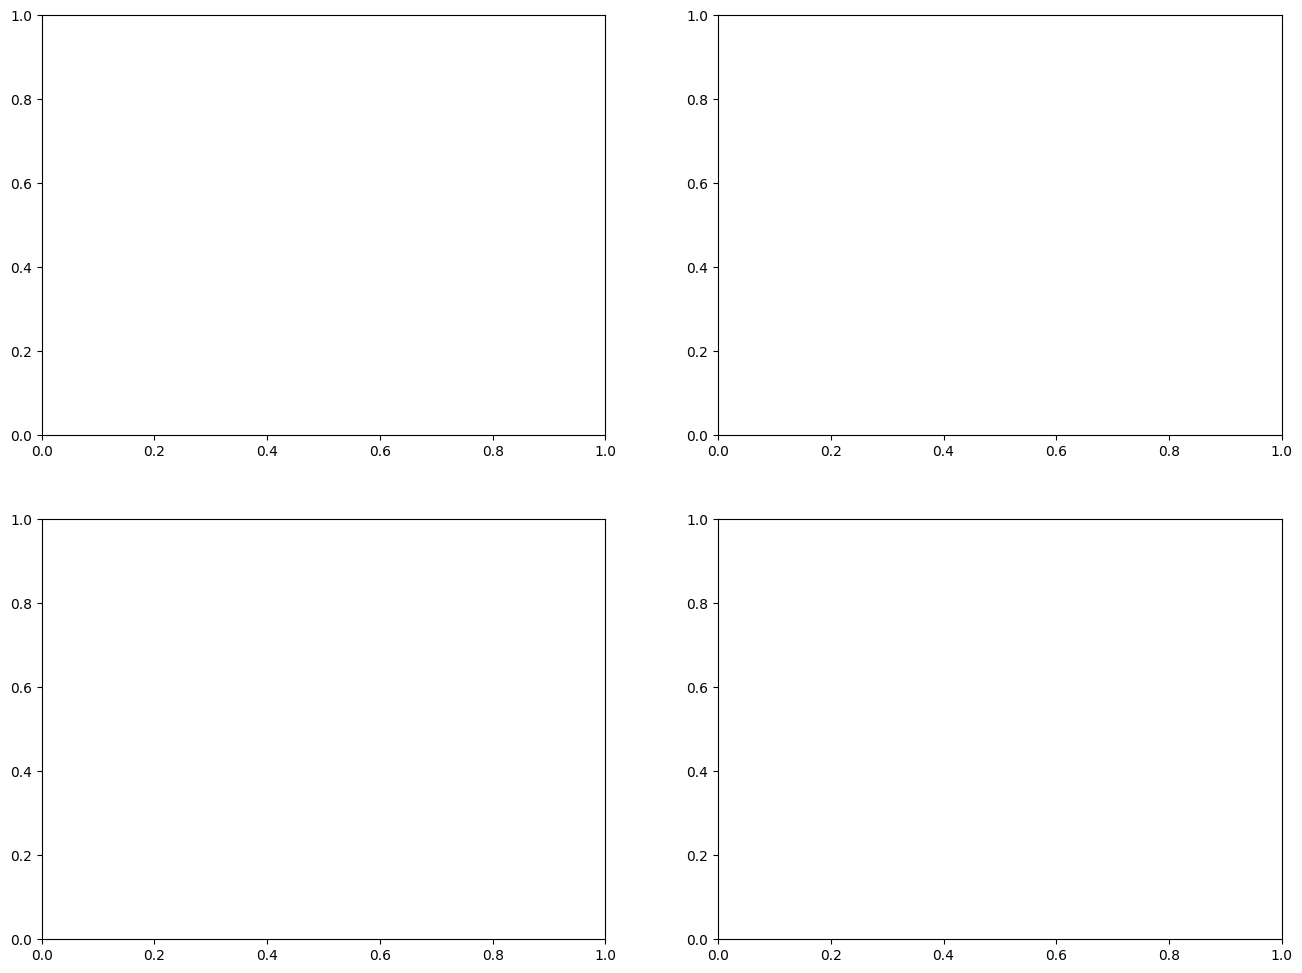

In [ ]:
# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colors = ['blue', 'red', 'green']

# Loss
for idx, (name, history) in enumerate(histories.items()):
    epochs = range(1, len(history['train_loss']) + 1)
    axes[0, 0].plot(epochs, history['train_loss'], f'{colors[idx]}-', 
                    label=f'{name} Train', linewidth=2, alpha=0.7)
    axes[0, 0].plot(epochs, history['val_loss'], f'{colors[idx]}--', 
                    label=f'{name} Val', linewidth=2, alpha=0.7)

axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Comparison', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
for idx, (name, history) in enumerate(histories.items()):
    epochs = range(1, len(history['train_acc']) + 1)
    axes[0, 1].plot(epochs, history['train_acc'], f'{colors[idx]}-', 
                    label=f'{name} Train', linewidth=2, alpha=0.7)
    axes[0, 1].plot(epochs, history['val_acc'], f'{colors[idx]}--', 
                    label=f'{name} Val', linewidth=2, alpha=0.7)

axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy Comparison', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# F1 Score
for idx, (name, history) in enumerate(histories.items()):
    epochs = range(1, len(history['val_f1']) + 1)
    axes[1, 0].plot(epochs, history['val_f1'], f'{colors[idx]}-', 
                    label=name, linewidth=2)

axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('Validation F1 Score Comparison', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Final metrics table
axes[1, 1].axis('off')
metrics_text = "FINAL METRICS (Best Epoch)\n\n"
for name, history in histories.items():
    metrics_text += f"{name}:\n"
    metrics_text += f"  Val Loss: {min(history['val_loss']):.4f}\n"
    metrics_text += f"  Val Acc:  {max(history['val_acc']):.4f}\n"
    metrics_text += f"  Val F1:   {max(history['val_f1']):.4f}\n\n"

axes[1, 1].text(0.1, 0.5, metrics_text, fontsize=11, family='monospace',
                verticalalignment='center')

plt.tight_layout()
plt.savefig('test_model_comparison.png', dpi=150)
plt.show()

print("✓ Comparison plotted")

## Section 5: Ablation Studies

Test variations of Conformer1DDual to optimize architecture

In [ ]:
print("="*80)
print("ABLATION STUDIES")
print("="*80)

ablation_configs = {
    'Spatial=2, Temporal=4 (baseline)': {'depth_spatial': 2, 'depth_temporal': 4, 'n_frames': 20},
    'Spatial=4, Temporal=4': {'depth_spatial': 4, 'depth_temporal': 4, 'n_frames': 20},
    'Spatial=2, Temporal=2': {'depth_spatial': 2, 'depth_temporal': 2, 'n_frames': 20},
    'Frames=10': {'depth_spatial': 2, 'depth_temporal': 4, 'n_frames': 10},
    'Frames=30': {'depth_spatial': 2, 'depth_temporal': 4, 'n_frames': 30},
}

ablation_results = {}

for config_name, config_params in ablation_configs.items():
    print(f"\nTesting: {config_name}")
    
    model_ablation = Conformer1DDual(
        emb_size=128,
        depth_spatial=config_params['depth_spatial'],
        depth_temporal=config_params['depth_temporal'],
        n_classes=2,
        max_channels=150,
        n_frames=config_params['n_frames']
    ).to(device)
    
    # Quick training (fewer epochs for ablation)
    history = train_model(model_ablation, config_name, train_loader, val_loader, 
                         num_epochs=15, lr=1e-3)
    
    ablation_results[config_name] = {
        'best_val_loss': min(history['val_loss']),
        'best_val_acc': max(history['val_acc']),
        'best_val_f1': max(history['val_f1']),
        'params': sum(p.numel() for p in model_ablation.parameters())
    }

print("\n" + "="*80)
print("ABLATION RESULTS SUMMARY")
print("="*80)

results_df = pd.DataFrame(ablation_results).T
print(results_df.to_string())

print("\n✓ Ablation studies complete")

ABLATION STUDIES

Testing: Spatial=2, Temporal=4 (baseline)

Training Spatial=2, Temporal=4 (baseline)...
Epoch  1: TrL=0.5728 TrA=0.7702 | VL=0.7377 VA=0.7864 VF1=0.4112
Epoch  6: TrL=0.4500 TrA=0.6844 | VL=0.3864 VA=0.7153 VF1=0.4167
Epoch 11: TrL=0.4537 TrA=0.6953 | VL=0.5381 VA=0.7458 VF1=0.4186
Epoch 15: TrL=0.4266 TrA=0.7091 | VL=0.4160 VA=0.6678 VF1=0.3718
✓ Best val loss: 0.3864

Testing: Spatial=4, Temporal=4

Training Spatial=4, Temporal=4...
Epoch  1: TrL=0.5848 TrA=0.6625 | VL=0.4433 VA=0.8000 VF1=0.4381
Epoch  6: TrL=0.4434 TrA=0.7396 | VL=0.3314 VA=0.8203 VF1=0.5225
Epoch 11: TrL=0.3235 TrA=0.8800 | VL=0.2952 VA=0.9424 VF1=0.7213
Epoch 15: TrL=0.3957 TrA=0.8196 | VL=0.2904 VA=0.8644 VF1=0.5833
✓ Best val loss: 0.2904

Testing: Spatial=2, Temporal=2

Training Spatial=2, Temporal=2...
Epoch  1: TrL=0.6371 TrA=0.6662 | VL=0.5016 VA=0.7492 VF1=0.3934
Epoch  6: TrL=0.4442 TrA=0.7040 | VL=0.5906 VA=0.8271 VF1=0.4950
Epoch 11: TrL=0.4818 TrA=0.6647 | VL=0.4499 VA=0.7424 VF1=0.41

## Section 6: Analysis and Recommendations

### Key Findings

**MultivarWav2Vec2 Issues Identified:**
1. Review the positional encoding test output above
2. Check the attention mask test results
3. Potential bugs: dimensions mismatch, improper masking of padded channels

**Conformer1DDual Performance:**
1. Compare training curves between single and dual transformer
2. Check if adding temporal transformer improves performance
3. Review ablation study results for optimal configuration

**Architecture Comparison:**
- Single Transformer (Conformer1D): Simpler, fewer parameters
- Dual Transformer (Conformer1DDual): More complex, captures both spatial and temporal patterns
- MultivarWav2Vec2: Most complex, but has implementation bugs

### Recommendations

Based on the results above:

1. **If Conformer1DDual performs better than Conformer1D**:
   - Use Conformer1DDual as the primary architecture
   - Create `benchmark/models/conformer/conformer_dual.py` with this implementation
   - Update training scripts to support dual-transformer option

2. **If single transformer is sufficient**:
   - Continue using Conformer1D
   - No need to add complexity

3. **For MultivarWav2Vec2**:
   - Document the bugs found (positional encoding, masking)
   - Consider deprecating if Conformer works better
   - Or fix bugs if architecture is important

4. **Next steps**:
   - Run full experiments with all patients using best model
   - Tune hyperparameters based on ablation results
   - Test on independent test set

In [ ]:
print("\n" + "="*80)
print("EXPERIMENTAL NOTEBOOK COMPLETE")
print("="*80)

print("\nGenerated files:")
print("  - test_model_comparison.png")

print("\nModels tested:")
for name in models_to_test.keys():
    print(f"  - {name}")

print("\nNext steps:")
print("  1. Review the results above")
print("  2. Choose the best performing architecture")
print("  3. If Conformer1DDual works well, create conformer_dual.py")
print("  4. Run full experiments with all patients")
print("  5. Document MultivarWav2Vec2 bugs if found")

print("\n✓ All experimental testing complete!")

## Test ConformerRegions with 256-dim embeddings and 12-layer transformer

This model uses:
- **4-layer CNN encoder** for richer feature extraction
- **256-dimensional embedding space** (doubled from 128)
- **12-layer transformer** (doubled from 6)
- **Region-based positional encoding** instead of learned positional embeddings

In [ ]:
# Import the updated ConformerRegions model
sys.path.insert(0, 'benchmark')
from models.conformer.conformer_regions import ConformerRegions

print("Testing ConformerRegions (emb_size=256, depth=12)")
print("=" * 80)

# Test forward pass
model_cr = ConformerRegions(
    emb_size=256,
    depth=12,
    num_heads=8,
    n_classes=2,
    dropout=0.1,
    max_channels=150,
    max_regions=42
).to(device)

# Test with a batch
test_signals = X_signals[:2].to(device)
test_regs = X_regs[:2].to(device)

with torch.no_grad():
    logits = model_cr(test_signals, test_regs)
    probs = F.softmax(logits, dim=1)
    
print(f"Input shape: {test_signals.shape}")
print(f"Regions shape: {test_regs.shape}")
print(f"Output logits shape: {logits.shape}")
print(f"Output logits: {logits}")
print(f"Output probs: {probs}")
print(f"\nModel parameters: {sum(p.numel() for p in model_cr.parameters()):,}")
print("✓ ConformerRegions forward pass successful!")

In [ ]:
# Train ConformerRegions model
print("\n" + "=" * 80)
print("Training ConformerRegions (emb_size=256, depth=12)")
print("=" * 80)

model_cr_train = ConformerRegions(
    emb_size=256,
    depth=12,
    num_heads=8,
    n_classes=2,
    dropout=0.1,
    max_channels=150,
    max_regions=42
).to(device)

history_cr = train_model(
    model_cr_train,
    "ConformerRegions (256-dim, 12-layer)",
    train_loader,
    val_loader,
    num_epochs=20,
    lr=1e-3
)

print("\n✓ ConformerRegions training complete")